# Plot the Cosine similarity versus Iteration number for different fluence

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
from IPython.display import display
from vector_ptycho.utils import _to_numpy

device = "cuda" if torch.cuda.is_available() else "cpu"

from vector_ptycho.utils import *
from vector_ptycho.plotting_utils import *
from vector_ptycho.Neel_field_sim_utils import *
from vector_ptycho.reconstruction_utils import *




In [2]:
RGB_scale = make_vector_color_map(plot=False)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
cdtype = torch.complex64
eps = 1e-8

print(device)

cuda


In [4]:
detector_pixel_size = 6.5e-6 * 4 # Pixel size of the detector (after binning)
wavelength = 1.74e-9 # Wavelength of the X-rays (1.74 nm corresponds to 720 eV)
z = 70e-3 # Sample to detector distance
k = 2 * np.pi / wavelength # Wave number
N = 512 # Number of pixels in the detector
L_detector = N * detector_pixel_size # Detector size

# Define the detector plane coordinates
x_detector = torch.linspace(-L_detector/2, L_detector/2, N, device=device)
y_detector = torch.linspace(-L_detector/2, L_detector/2, N, device=device)
X_detector, Y_detector = torch.meshgrid(x_detector, y_detector, indexing='ij')

# Define the sample plane coordinates
object_pixel_size = (wavelength * z) / (N * detector_pixel_size) # Pixel size in the object/probe plane


L_object = N * object_pixel_size # Object size
x_obj = torch.linspace(-L_object/2, L_object/2, N, device=device)
y_obj = torch.linspace(-L_object/2, L_object/2, N, device=device)
X_obj, Y_obj = torch.meshgrid(x_obj, y_obj, indexing='ij')

print(f"Object pixel size: {object_pixel_size:.2e} m")
print(f"Object size: {L_object:.2e} m")

Object pixel size: 9.15e-09 m
Object size: 4.68e-06 m


In [5]:
H, W = N, N
Lx = N * object_pixel_size
Ly = N * object_pixel_size

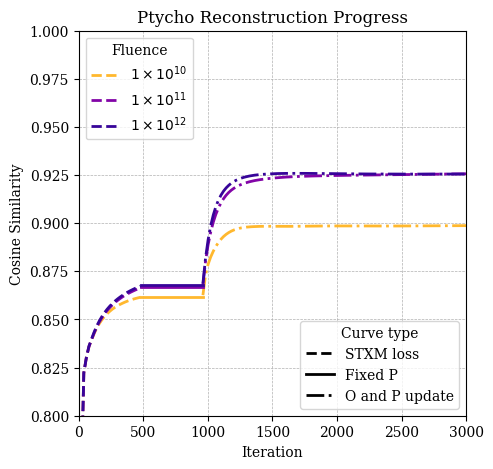

<Figure size 640x480 with 0 Axes>

In [15]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Serif'
# Plasma colour scheme
light_yellow = '#ffb82e'
pinky = '#cf4c73'
light_purple = '#8204a7'
dark_purple = '#370499'

run_files_1e10 = [r'.\fluence_1e10\recon_STXM.pt',
              r'.\fluence_1e10\recon_post_STXM.pt',
                r'.\fluence_1e10\recon_post_STXM_2.pt']

run_files_1e11 = [r'.\fluence_1e11\recon_STXM.pt',
              r'.\fluence_1e11\recon_post_STXM.pt',
                r'.\fluence_1e11\recon_post_STXM_2.pt']

run_files_1e12 = [r'.\fluence_1e12\recon_STXM.pt',
              r'.\fluence_1e12\recon_post_STXM.pt',
                r'.\fluence_1e12\recon_post_STXM_2.pt']

# Each stage of the reconstruction has a different line style.
line_styles = ['--', '-', '-.']
colours = [light_yellow, light_purple, dark_purple]

fig, ax = plt.subplots(figsize=(5, 5))

plot_checkpoint_history(
    run_files_1e10,
    label=r"$1\times 10^{10}$",
    ax=ax,
    linewidth=2,
    line_styles=line_styles,
    colour=colours[0]
)
plot_checkpoint_history(
    run_files_1e11,
    label=r"$1\times 10^{11}$",
    ax=ax,
    linewidth=2,
    line_styles=line_styles,
    colour=colours[1]
)
plot_checkpoint_history(
    run_files_1e12,
    label=r"$1\times 10^{12}$",
    ax=ax,
    linewidth=2,
    line_styles=line_styles,
    colour=colours[2]
)

# Colour legend (generated automatically from plotted lines)
colour_legend = ax.legend(title="Fluence", loc="upper left")

# Linestyle legend
style_labels = ["STXM loss", "Fixed P", "O and P update"]

style_handles = [
    Line2D([0], [0], color='black', linestyle=ls, linewidth=2, label=lbl)
    for ls, lbl in zip(line_styles, style_labels)
]

style_legend = ax.legend(
    handles=style_handles,
    title="Curve type",
    loc="lower right"
)

# Add the first legend back after creating the second
ax.add_artist(colour_legend)
# Add a horizontal dashed line at y=1.0 to indicate perfect cosine similarity
#ax.plot([0, 3000], [1.0, 1.0], color='black', linestyle=':', linewidth=1)
ax.set_ylim(0.8, 1.00)
#ax.set_ylim(0.9, 0.95)
ax.set_xlim(0, 3000)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
plt.savefig("ptycho_recon_progress_1e10_1e11_1e12.svg", dpi=300)